# Baseline — LightGBM
Entrée : `X.parquet` + `y.parquet` → Modèle de référence avant MLP

- Train / Validation / Test split (70 / 15 / 15)
- LightGBM sur la cible électricité (une cible à la fois)
- Métriques : RMSE, MAE, R²
- Feature importance

In [13]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

ROOT           = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

X = pd.read_parquet(DATA_PROCESSED / 'X.parquet')
y = pd.read_parquet(DATA_PROCESSED / 'y.parquet')

print('X :', X.shape)
print('y :', y.shape)
print('\nCibles :')
for col in y.columns:
    n_zeros = (y[col] == 0).sum()
    print(f'  {col.split(".")[1]:<15} zéros={n_zeros/len(y)*100:.1f}%  mean={y[col].mean():.1f}')

X : (549971, 110)
y : (549971, 5)

Cibles :
  electricity     zéros=0.0%  mean=11755.6
  natural_gas     zéros=39.5%  mean=10592.5
  fuel_oil        zéros=95.0%  mean=1280.7
  propane         zéros=91.6%  mean=1103.6
  emissions       zéros=0.6%  mean=5427.3


## 1. Train / Validation / Test split stratifié
Stratification sur **zone climatique × type de bâtiment × vintage groupé** pour garantir une représentation équilibrée dans chaque split.

- 17 zones × 5 types × 3 groupes vintage ≈ 255 combinaisons
- ~2 157 lignes par groupe en moyenne → largement suffisant

In [14]:
import re

SEED = 42

# ── Charger les colonnes originales pour la stratification ───────────────────
meta = pd.read_parquet(DATA_PROCESSED / 'metadata_clean.parquet',
                       columns=['in.ashrae_iecc_climate_zone_2004',
                                'in.geometry_building_type_recs',
                                'in.vintage'])

# ── Vintage → 3 groupes (<1980 / 1980-2000 / >2000) ─────────────────────────
def vintage_group(val):
    if pd.isna(val): return 'inconnu'
    s = str(val).strip()
    m = re.match(r'(\d{4})s?', s)
    if not m: return 'avant_1980'
    decade = int(m.group(1))
    if decade < 1980:  return 'avant_1980'
    if decade < 2000:  return '1980_2000'
    return 'apres_2000'

meta['vintage_group'] = meta['in.vintage'].apply(vintage_group)

# ── Clé combinée : zone__type__vintage ───────────────────────────────────────
meta['strat_key'] = (
    meta['in.ashrae_iecc_climate_zone_2004'].astype(str) + '__' +
    meta['in.geometry_building_type_recs'].astype(str)  + '__' +
    meta['vintage_group']
)

print(f'Combinaisons uniques       : {meta["strat_key"].nunique()}')
print(f'Taille min. par combinaison: {meta["strat_key"].value_counts().min()}')
print(f'Taille moy. par combinaison: {meta["strat_key"].value_counts().mean():.0f}')

# ── Split 70 / 15 / 15 ───────────────────────────────────────────────────────
#strat = meta['strat_key'].values
mask = meta['strat_key'] != '8AK__Mobile Home__apres_2000'

X = X[mask]
y = y[mask]
meta = meta[mask]

'''X_train, X_temp, y_train, y_temp, s_temp = train_test_split(
    X, y, strat, test_size=0.30, random_state=SEED, stratify=strat
)
'''
strat = meta['strat_key']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=meta['strat_key']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED
)
print(f'\nTrain : {X_train.shape[0]:>7} lignes')
print(f'Val   : {X_val.shape[0]:>7} lignes')
print(f'Test  : {X_test.shape[0]:>7} lignes')

Combinaisons uniques       : 255
Taille min. par combinaison: 1
Taille moy. par combinaison: 2157

Train :  384979 lignes
Val   :   82495 lignes
Test  :   82496 lignes


## 2. Baseline naïve — référence minimum
Prédire la médiane du train sur tout le test. LightGBM doit faire mieux que ça.

In [15]:
from sklearn.dummy import DummyRegressor

TARGET = 'out.electricity.total.energy_consumption..kwh'

dummy = DummyRegressor(strategy='median')
dummy.fit(X_train, y_train[TARGET])
y_pred_dummy = dummy.predict(X_test)

rmse_dummy = np.sqrt(mean_squared_error(y_test[TARGET], y_pred_dummy))
mae_dummy  = mean_absolute_error(y_test[TARGET], y_pred_dummy)
r2_dummy   = r2_score(y_test[TARGET], y_pred_dummy)

print(f'Baseline naïve (médiane)  RMSE={rmse_dummy:>8.1f}  MAE={mae_dummy:>8.1f}  R²={r2_dummy:.4f}')
print('LightGBM doit dépasser ces valeurs pour apporter de la valeur.')

Baseline naïve (médiane)  RMSE=  8950.4  MAE=  6024.9  R²=-0.0603
LightGBM doit dépasser ces valeurs pour apporter de la valeur.


In [16]:
TARGET = 'out.electricity.total.energy_consumption..kwh'

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
)

model.fit(
    X_train, y_train[TARGET],
    eval_set=[(X_val, y_val[TARGET])],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

print(f'Meilleure itération : {model.best_iteration_}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 384979, number of used features: 110
[LightGBM] [Info] Start training from score 11745.545839
[100]	valid_0's l2: 1.60404e+07
[200]	valid_0's l2: 1.34646e+07
[300]	valid_0's l2: 1.25197e+07
[400]	valid_0's l2: 1.20459e+07
[500]	valid_0's l2: 1.17751e+07
Meilleure itération : 500


## 3. Métriques

In [17]:
def evaluate(model, X, y_true, split_name):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{split_name:<6}  RMSE={rmse:>8.1f}  MAE={mae:>8.1f}  R²={r2:.4f}')
    return y_pred

print(f'Cible : {TARGET}\n')
evaluate(model, X_train, y_train[TARGET], 'Train')
evaluate(model, X_val,   y_val[TARGET],   'Val')
y_pred_test = evaluate(model, X_test, y_test[TARGET], 'Test')

Cible : out.electricity.total.energy_consumption..kwh

Train   RMSE=  3095.7  MAE=  1658.8  R²=0.8709
Val     RMSE=  3431.5  MAE=  1762.4  R²=0.8388
Test    RMSE=  3534.9  MAE=  1792.3  R²=0.8346


## 4. Feature Importance — Top 20

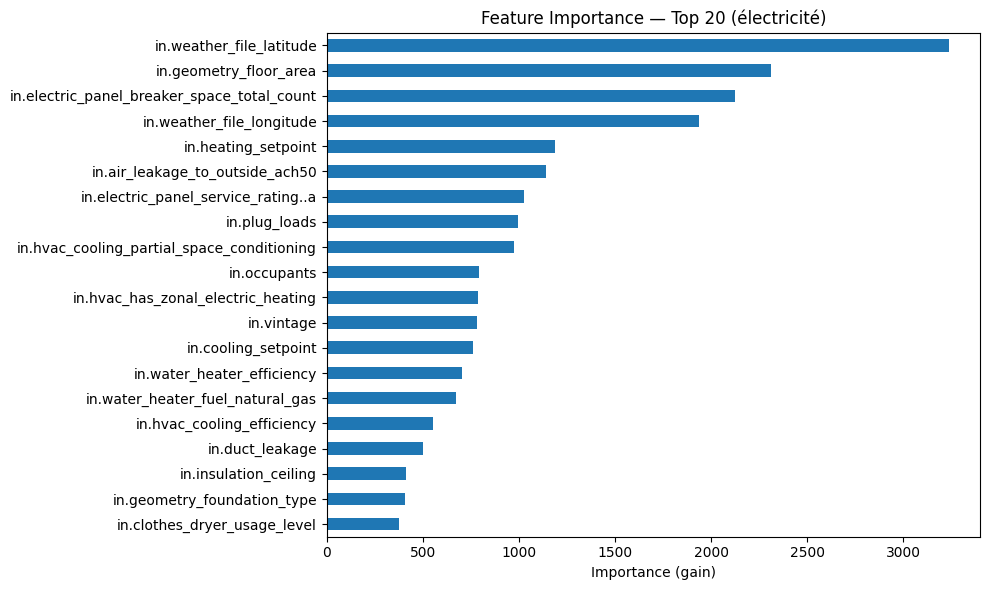


Top 20 features :
in.weather_file_latitude                       3238
in.geometry_floor_area                         2312
in.electric_panel_breaker_space_total_count    2124
in.weather_file_longitude                      1936
in.heating_setpoint                            1187
in.air_leakage_to_outside_ach50                1141
in.electric_panel_service_rating..a            1024
in.plug_loads                                   997
in.hvac_cooling_partial_space_conditioning      975
in.occupants                                    792
in.hvac_has_zonal_electric_heating              789
in.vintage                                      781
in.cooling_setpoint                             761
in.water_heater_efficiency                      703
in.water_heater_fuel_natural_gas                674
in.hvac_cooling_efficiency                      552
in.duct_leakage                                 503
in.insulation_ceiling                           410
in.geometry_foundation_type                  

In [18]:
importance = pd.Series(model.feature_importances_, index=X.columns)
top20 = importance.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Feature Importance — Top 20 (électricité)')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

print('\nTop 20 features :')
print(top20.to_string())

## 5. Prédictions vs Réel (test set)

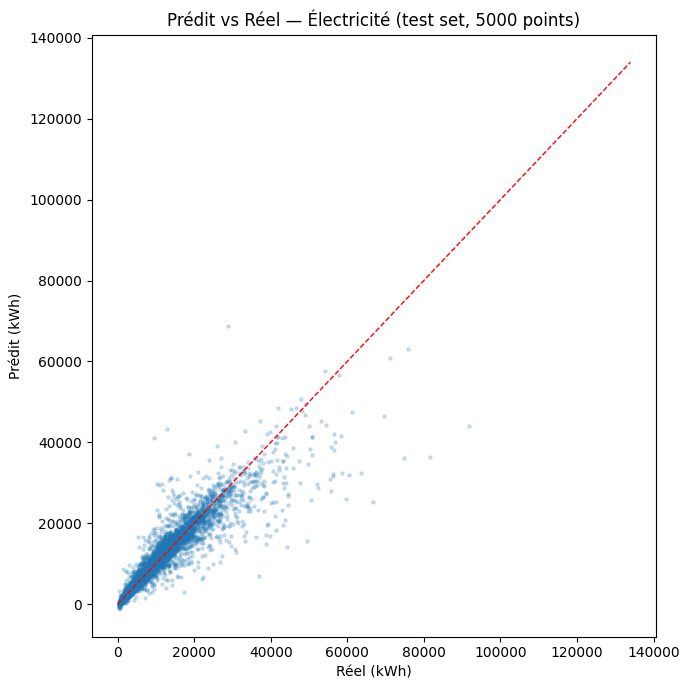

In [19]:
fig, ax = plt.subplots(figsize=(7, 7))
sample = np.random.choice(len(y_test), size=5000, replace=False)
ax.scatter(y_test[TARGET].iloc[sample], y_pred_test[sample], alpha=0.2, s=5)
lim = max(y_test[TARGET].max(), y_pred_test.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
ax.set_xlabel('Réel (kWh)')
ax.set_ylabel('Prédit (kWh)')
ax.set_title('Prédit vs Réel — Électricité (test set, 5000 points)')
plt.tight_layout()
plt.show()